# AQI Data Pipeline
# Author: Mayank Savani
# Date: June 2026
# Description: Data collection, cleaning and EDA for AQI Severity Prediction

In [9]:
# Cell 1 - Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported!
PyTorch version: 2.11.0+cpu


In [10]:
# Cell 2 - Load clean dataset from Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the clean dataset we saved earlier
df = pd.read_csv('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/AQI_Clean_Dataset.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nAQI Category distribution:")
print(df['AQI_Category'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (9399, 16)

Columns: ['Timestamp', 'PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'RH', 'WS', 'WD', 'City', 'AQI', 'AQI_Category', 'Month', 'Year']

AQI Category distribution:
AQI_Category
Satisfactory    3588
Moderate        2846
Good            1394
Very Poor        582
Poor             578
Severe           411
Name: count, dtype: int64


In [11]:
# Cell 3 - Feature Engineering & Preprocessing

# Step 1 - Drop columns not needed for model
df = df.drop(columns=['Timestamp', 'AQI'])
# Why drop AQI? We're predicting AQI_Category, not the number.
# Keeping AQI would be "data leakage" - model would just learn AQI→Category mapping, not the actual pollutant patterns.

# Step 2 - One-hot encode City column
df = pd.get_dummies(df, columns=['City'], prefix='City')
# Why one-hot? City is categorical - Delhi=1, Mumbai=2 is wrong because
# it implies Mumbai is "twice" Delhi. One-hot treats each city independently.

# Step 3 - Encode target variable (AQI_Category → numbers)
le = LabelEncoder()
df['AQI_Category'] = le.fit_transform(df['AQI_Category'])
print(f"Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Step 4 - Split features and target
X = df.drop(columns=['AQI_Category'])
y = df['AQI_Category']
print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

Class mapping:
  0 → Good
  1 → Moderate
  2 → Poor
  3 → Satisfactory
  4 → Severe
  5 → Very Poor

Feature shape: (9399, 17)
Target shape: (9399,)
Features: ['PM25', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'RH', 'WS', 'WD', 'Month', 'Year', 'City_Bengaluru', 'City_Chennai', 'City_Delhi', 'City_Kolkata', 'City_Mumbai']


In [12]:
# Cell 4 - Train-Test Split + Scaling + Class Weights

# Step 1 - Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Why stratify=y? Ensures each split has same class proportions.
# Without it, test set might accidentally have no "Severe" days.

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Step 2 - Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Why StandardScaler? Converts all features to mean=0, std=1.
# PM25 ranges 0-500, WS ranges 0-5 — without scaling,
# PM25 would dominate and WS would be ignored by the ANN.
# CRITICAL: fit only on training data, transform both.
# Fitting on test data = data leakage.

# Step 3 - Compute Class Weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights)
print(f"\nClass weights (to handle imbalance):")
for i, (cls, w) in enumerate(zip(le.classes_, class_weights)):
    print(f"  {cls}: {w:.3f}")

# Step 4 - Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

# Step 5 - Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Why shuffle=True for train only?
# Training: shuffle so model doesn't learn order patterns.
# Testing: no shuffle so results are reproducible.

print(f"\n Data ready for PyTorch!")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 7519
Testing samples:  1880

Class weights (to handle imbalance):
  Good: 1.124
  Moderate: 0.550
  Poor: 2.712
  Satisfactory: 0.437
  Severe: 3.809
  Very Poor: 2.689

 Data ready for PyTorch!
Train batches: 235
Test batches: 59


In [13]:
# Cell 5 - ANN Model Architecture

class AQI_ANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(AQI_ANN, self).__init__()

        self.network = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output Layer
            nn.Linear(32, num_classes)
        )
        # Why no Softmax here?
        # PyTorch's CrossEntropyLoss applies Softmax internally.
        # Adding it manually would cause double-softmax = wrong probabilities.

    def forward(self, x):
        return self.network(x)

# Initialize model
input_size = X_train_tensor.shape[1]  # 17 features
num_classes = len(le.classes_)         # 6 classes
model = AQI_ANN(input_size, num_classes)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Print model summary
print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input size: {input_size}")
print(f"Output classes: {num_classes}")

Model Architecture:
AQI_ANN(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=6, bias=True)
  )
)

Total parameters: 13,286
Input size: 17
Output classes: 6


In [6]:
# Cell 6 - Training Loop

# Training configuration
num_epochs = 100
best_accuracy = 0
patience = 10  # Early stopping patience
patience_counter = 0

# Track losses for plotting
train_losses = []
val_accuracies = []

print(" Starting Training...")
print("="*60)

# took me a while to figure out why val accuracy was fluctuating
# turns out BatchNorm behaves differently in train vs eval mode - model.train() vs model.eval()

for epoch in range(num_epochs):

    # ---- TRAINING PHASE ----
    model.train()
    # Why model.train()? Activates Dropout and BatchNorm in training mode.

    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()        # Clear previous gradients
        outputs = model(batch_X)     # Forward pass
        loss = criterion(outputs, batch_y)  # Calculate loss
        loss.backward()              # Backpropagation
        optimizer.step()             # Update weights
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- VALIDATION PHASE ----
    model.eval()
    # Why model.eval()? Deactivates Dropout — we want full network for evaluation.

    correct = 0
    total = 0
    with torch.no_grad():
        # Why no_grad()? We're not training here — no need to
        # calculate gradients. Saves memory and speeds up evaluation.
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/100] | Loss: {avg_train_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

    # ---- EARLY STOPPING ----
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            print(f"No improvement for {patience} epochs.")
            break

print("="*60)
print(f"\n Training Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.2f}%")

 Starting Training...
Epoch [ 10/100] | Loss: 0.6127 | Val Accuracy: 81.33%
Epoch [ 20/100] | Loss: 0.5415 | Val Accuracy: 84.63%
Epoch [ 30/100] | Loss: 0.4710 | Val Accuracy: 84.10%

 Early stopping at epoch 37
No improvement for 10 epochs.

 Training Complete!
Best Validation Accuracy: 86.76%


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.84      0.87      0.86       279
    Moderate       0.91      0.85      0.88       569
        Poor       0.63      0.99      0.77       116
Satisfactory       0.89      0.87      0.88       718
      Severe       0.91      0.94      0.92        82
   Very Poor       0.96      0.76      0.85       116

    accuracy                           0.87      1880
   macro avg       0.86      0.88      0.86      1880
weighted avg       0.88      0.87      0.87      1880



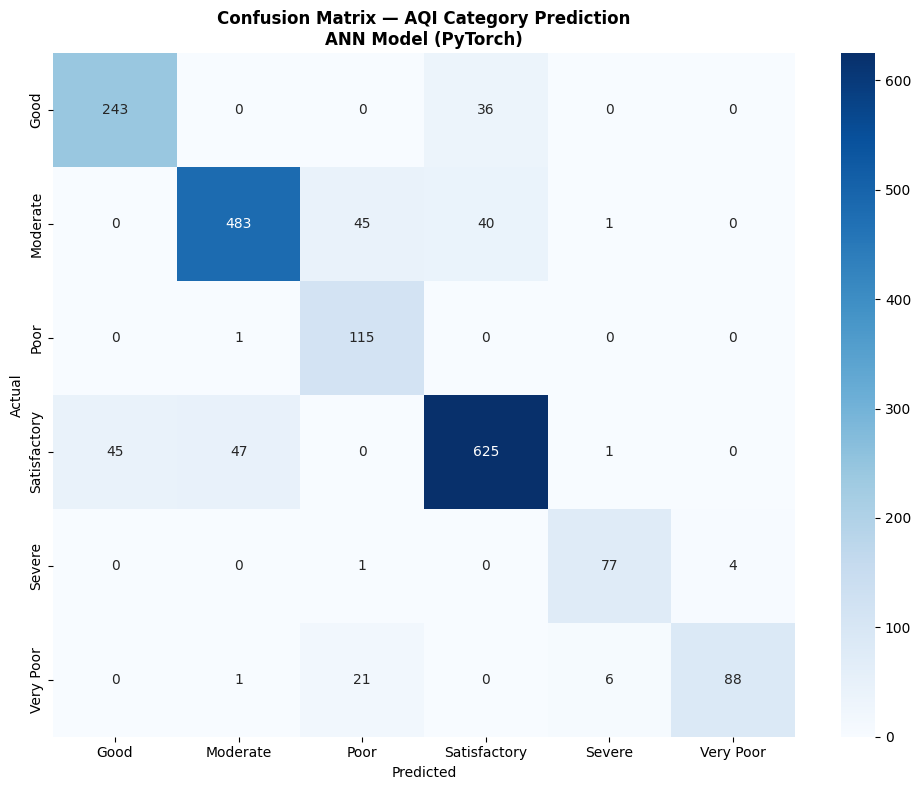

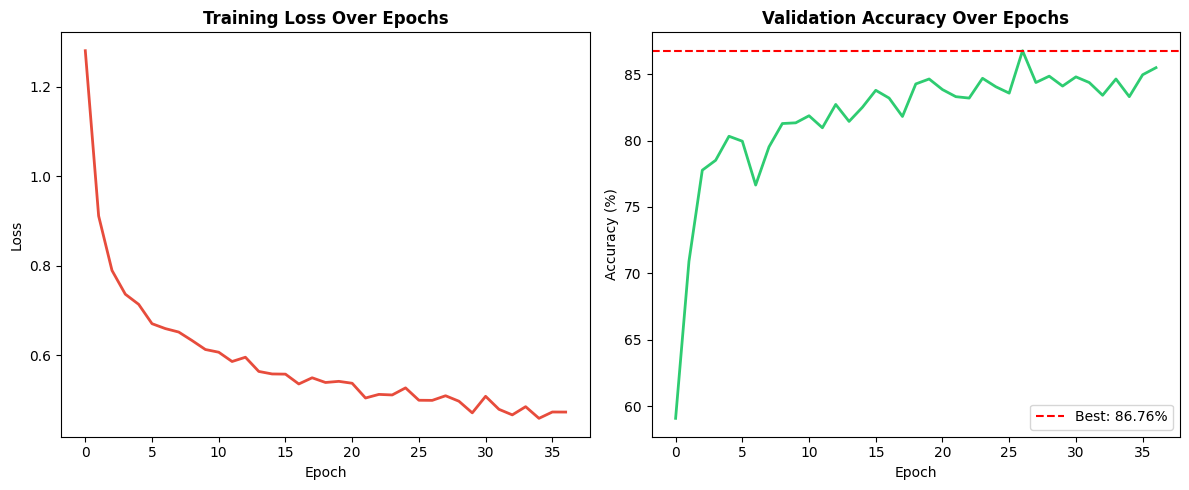

Evaluation complete!


In [7]:
# Cell 7 - Full Model Evaluation

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get all predictions
all_predictions = []
all_actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.numpy())
        all_actuals.extend(batch_y.numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Classification Report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    all_actuals,
    all_predictions,
    target_names=le.classes_
))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_actuals, all_predictions)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — AQI Category Prediction\nANN Model (PyTorch)',
          fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot7_Confusion_Matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Training curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='#e74c3c', linewidth=2)
plt.title('Training Loss Over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, color='#2ecc71', linewidth=2)
plt.axhline(y=best_accuracy, color='red', linestyle='--',
            label=f'Best: {best_accuracy:.2f}%')
plt.title('Validation Accuracy Over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AQI_DL_ANN_PROJECT/Plot8_Training_Curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation complete!")

In [8]:
# Cell 8 - Save model and scaler to Drive
import pickle

save_dir = '/content/drive/MyDrive/AQI_DL_ANN_PROJECT'

# Save PyTorch model
torch.save(model.state_dict(),
           f'{save_dir}/AQI_ANN_model.pth')

# Save scaler - needed for future predictions
with open(f'{save_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoder - needed to decode predictions
with open(f'{save_dir}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(" Model saved!")
print(" Scaler saved!")
print(" Label Encoder saved!")
print(f"\nAll files saved to: {save_dir}")

 Model saved!
 Scaler saved!
 Label Encoder saved!

All files saved to: /content/drive/MyDrive/AQI_DL_ANN_PROJECT
